# Listing raw files

In [2]:
from pyspark.sql import SparkSession
from notebookutils import mssparkutils

spark = SparkSession.builder.getOrCreate()

# list files in your Lakehouse folder
files = mssparkutils.fs.ls("Files/raw_fitbit")
[(f.name, f.path, f.size) for f in files][:10]


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 4, Finished, Available, Finished)

[('dailyActivity_merged.csv',
  'abfss://e400e014-3fee-49ee-a408-617541391102@onelake.dfs.fabric.microsoft.com/5bd8b421-6f82-4926-adda-cc6b2554b0e1/Files/raw_fitbit/dailyActivity_merged.csv',
  111288),
 ('dailyCalories_merged.csv',
  'abfss://e400e014-3fee-49ee-a408-617541391102@onelake.dfs.fabric.microsoft.com/5bd8b421-6f82-4926-adda-cc6b2554b0e1/Files/raw_fitbit/dailyCalories_merged.csv',
  25125),
 ('dailyIntensities_merged.csv',
  'abfss://e400e014-3fee-49ee-a408-617541391102@onelake.dfs.fabric.microsoft.com/5bd8b421-6f82-4926-adda-cc6b2554b0e1/Files/raw_fitbit/dailyIntensities_merged.csv',
  70581),
 ('dailySteps_merged.csv',
  'abfss://e400e014-3fee-49ee-a408-617541391102@onelake.dfs.fabric.microsoft.com/5bd8b421-6f82-4926-adda-cc6b2554b0e1/Files/raw_fitbit/dailySteps_merged.csv',
  25175),
 ('heartrate_seconds_merged.csv',
  'abfss://e400e014-3fee-49ee-a408-617541391102@onelake.dfs.fabric.microsoft.com/5bd8b421-6f82-4926-adda-cc6b2554b0e1/Files/raw_fitbit/heartrate_seconds_merg

In [3]:
df_files = spark.createDataFrame([(f.name, f.path, f.size) for f in files], ["name","path","size"])
display(df_files)


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 5, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, 0d3fa954-fe8d-4445-9be1-ea49941b9562)

## Verify the notebook is attached to the lakehouse

In [4]:
# 1) Should show your lakehouse database
spark.sql("SHOW DATABASES").show(truncate=False)

# 2) Try writing a tiny temp table
spark.range(5).write.mode("overwrite").saveAsTable("attach_check_table")
spark.sql("SHOW TABLES").show(truncate=False)


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 6, Finished, Available, Finished)

+-------------------------------------------+
|namespace                                  |
+-------------------------------------------+
|fitbit_lakehouse                           |
|StagingLakehouseForDataflows_20251005221627|
+-------------------------------------------+

+----------------+------------------+-----------+
|namespace       |tableName         |isTemporary|
+----------------+------------------+-----------+
|fitbit_lakehouse|attach_check_table|false      |
+----------------+------------------+-----------+



# Loading dailyActivity_merged.csv

In [5]:
from pyspark.sql.functions import col, to_date

df_activity = (
    spark.read.option("header", True).option("inferSchema", True)
         .csv("Files/raw_fitbit/dailyActivity_merged.csv")
    .withColumn("Date", to_date(col("ActivityDate"), "M/d/yyyy"))
    .drop("ActivityDate")
    .dropDuplicates(["Id","Date"])
)

display(df_activity.limit(10))
print("Rows:", df_activity.count(), "Users:", df_activity.select("Id").distinct().count())
df_activity.printSchema()


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 7, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, b6c2afc3-440c-4a3f-9a2c-81a6e248b77a)

Rows: 940 Users: 33
root
 |-- Id: long (nullable = true)
 |-- TotalSteps: integer (nullable = true)
 |-- TotalDistance: double (nullable = true)
 |-- TrackerDistance: double (nullable = true)
 |-- LoggedActivitiesDistance: double (nullable = true)
 |-- VeryActiveDistance: double (nullable = true)
 |-- ModeratelyActiveDistance: double (nullable = true)
 |-- LightActiveDistance: double (nullable = true)
 |-- SedentaryActiveDistance: double (nullable = true)
 |-- VeryActiveMinutes: integer (nullable = true)
 |-- FairlyActiveMinutes: integer (nullable = true)
 |-- LightlyActiveMinutes: integer (nullable = true)
 |-- SedentaryMinutes: integer (nullable = true)
 |-- Calories: integer (nullable = true)
 |-- Date: date (nullable = true)



## Save cleaned base

In [6]:
df_activity.repartition("Date").write.mode("overwrite").saveAsTable("daily_activity_cleaned")

(df_activity.repartition("Date")
 .write.mode("overwrite")
 .parquet("Files/interim_fitbit/daily_activity_cleaned"))


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 8, Finished, Available, Finished)

# load and clean sleepDay_merged.csv

In [8]:
from pyspark.sql.functions import col, to_date

# 1️ load
df_sleep = (
    spark.read.option("header", True)
              .option("inferSchema", True)
              .csv("Files/raw_fitbit/sleepDay_merged.csv")
)

# 2️ parse datetime → date only
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")

df_sleep = (
    df_sleep.withColumn("Date", to_date(col("SleepDay"), "M/d/yyyy hh:mm:ss a"))
             .drop("SleepDay")
)


# 3️ drop duplicates on (Id, Date)
df_sleep = df_sleep.dropDuplicates(["Id", "Date"])

# 4️  basic sanity filter (remove impossible zeros / negatives)
for c in ["TotalSleepRecords", "TotalMinutesAsleep", "TotalTimeInBed"]:
    df_sleep = df_sleep.filter(col(c).isNull() | (col(c) >= 0))

# 5️  quick peek
display(df_sleep.limit(10))
print("Rows:", df_sleep.count(), "  Users:", df_sleep.select("Id").distinct().count())
df_sleep.printSchema()


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 10, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, 3b6c50f7-6e32-473e-9ad7-d626ec27d981)

Rows: 410   Users: 24
root
 |-- Id: long (nullable = true)
 |-- TotalSleepRecords: integer (nullable = true)
 |-- TotalMinutesAsleep: integer (nullable = true)
 |-- TotalTimeInBed: integer (nullable = true)
 |-- Date: date (nullable = true)



## Created a sleep-efficiency column

In [9]:
from pyspark.sql.functions import when, round

df_sleep = df_sleep.withColumn(
    "SleepEfficiency",
    when(col("TotalTimeInBed") > 0, round(col("TotalMinutesAsleep") / col("TotalTimeInBed"), 3)).otherwise(None)
)


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 11, Finished, Available, Finished)

## Save cleaned sleep data

In [10]:
# Lakehouse table
df_sleep.repartition("Date").write.mode("overwrite").saveAsTable("daily_sleep_cleaned")

# Optional Parquet copy
(df_sleep.repartition("Date")
 .write.mode("overwrite")
 .parquet("Files/interim_fitbit/daily_sleep_cleaned"))


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 12, Finished, Available, Finished)

# Aggregate Hourly, Minute & Heart-Rate Data to Daily Summaries

### A. Hourly Data (steps / calories / intensities)

In [11]:
from pyspark.sql.functions import to_date, col, sum as _sum, avg

# ---------- hourly STEPS ----------
df_hourly_steps = (
    spark.read.option("header", True).option("inferSchema", True)
    .csv("Files/raw_fitbit/hourlySteps_merged.csv")
    .withColumn("Date", to_date(col("ActivityHour"), "M/d/yyyy H:mm:ss a"))
)

df_hourly_steps_daily = (
    df_hourly_steps.groupBy("Id", "Date")
                   .agg(_sum("StepTotal").alias("Steps_HourlySum"))
)

# ---------- hourly CALORIES ----------
df_hourly_calories = (
    spark.read.option("header", True).option("inferSchema", True)
    .csv("Files/raw_fitbit/hourlyCalories_merged.csv")
    .withColumn("Date", to_date(col("ActivityHour"), "M/d/yyyy H:mm:ss a"))
)

df_hourly_calories_daily = (
    df_hourly_calories.groupBy("Id", "Date")
                      .agg(_sum("Calories").alias("Calories_HourlySum"))
)

# ---------- hourly INTENSITIES ----------
df_hourly_intensities = (
    spark.read.option("header", True).option("inferSchema", True)
    .csv("Files/raw_fitbit/hourlyIntensities_merged.csv")
    .withColumn("Date", to_date(col("ActivityHour"), "M/d/yyyy H:mm:ss a"))
)

df_hourly_intensities_daily = (
    df_hourly_intensities.groupBy("Id", "Date")
                         .agg(
                             _sum("TotalIntensity").alias("TotalIntensity_Daily"),
                             avg("AverageIntensity").alias("AvgIntensity_Daily")
                         )
)


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 13, Finished, Available, Finished)

### Heart-Rate (aggregate by day)

In [12]:
from pyspark.sql.functions import min as _min, max as _max, mean as _mean, stddev

df_hr = (
    spark.read.option("header", True).option("inferSchema", True)
    .csv("Files/raw_fitbit/heartrate_seconds_merged.csv")
    .withColumn("Date", to_date(col("Time"), "M/d/yyyy H:mm:ss a"))
)

df_hr_daily = (
    df_hr.groupBy("Id", "Date")
         .agg(
             _min("Value").alias("HR_Min"),
             _max("Value").alias("HR_Max"),
             _mean("Value").alias("HR_Mean"),
             stddev("Value").alias("HR_StdDev")
         )
)


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 14, Finished, Available, Finished)

### Save Daily Summaries to Lakehouse

In [13]:
datasets = {
    "hourly_steps_daily": df_hourly_steps_daily,
    "hourly_calories_daily": df_hourly_calories_daily,
    "hourly_intensities_daily": df_hourly_intensities_daily,
    "heartrate_daily": df_hr_daily
}

for name, df in datasets.items():
    df.repartition("Date").write.mode("overwrite").saveAsTable(name)
    df.repartition("Date").write.mode("overwrite").parquet(f"Files/interim_fitbit/{name}")


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 15, Finished, Available, Finished)

## Load all cleaned daily tables

In [14]:
# base datasets (cleaned or aggregated)
df_activity = spark.read.table("daily_activity_cleaned")
df_sleep = spark.read.table("daily_sleep_cleaned")
df_hr_daily = spark.read.table("heartrate_daily")
df_hourly_steps = spark.read.table("hourly_steps_daily")
df_hourly_calories = spark.read.table("hourly_calories_daily")
df_hourly_intensities = spark.read.table("hourly_intensities_daily")


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 16, Finished, Available, Finished)

# Join on Id + Date (using left joins)

In [15]:
from functools import reduce

# define all tables to join
join_list = [df_sleep, df_hr_daily, df_hourly_steps, df_hourly_calories, df_hourly_intensities]

# start from base activity table
df_master = df_activity

for df in join_list:
    df_master = (
        df_master.join(df, on=["Id", "Date"], how="left")
    )

display(df_master.limit(10))
print("Final rows:", df_master.count(), "  Columns:", len(df_master.columns))


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 17, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, 32ef992a-8877-458b-977f-193043b17100)

Final rows: 940   Columns: 27


## Optional cleaning & feature prep

In [16]:
from pyspark.sql.functions import when, round, col

# derive engagement flag
df_master = df_master.withColumn(
    "Engaged",
    when((col("TotalSteps") > 0) | (col("Calories") > 1200), 1).otherwise(0)
)

# replace negative or nonsense values with null
for c in ["Calories_HourlySum", "Steps_HourlySum", "TotalMinutesAsleep", "HR_Mean"]:
    df_master = df_master.withColumn(c, when(col(c) >= 0, col(c)).otherwise(None))


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 18, Finished, Available, Finished)

# Save final unified dataset

In [17]:
# Lakehouse table
df_master.repartition("Date").write.mode("overwrite").saveAsTable("fitbit_daily_master")

# Optional Parquet copy
(df_master.repartition("Date")
 .write.mode("overwrite")
 .parquet("Files/processed_fitbit/fitbit_daily_master"))


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 19, Finished, Available, Finished)

In [18]:
df_master.groupBy("Engaged").count().show()
df_master.select("Id").distinct().count()


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 20, Finished, Available, Finished)

+-------+-----+
|Engaged|count|
+-------+-----+
|      1|  933|
|      0|    7|
+-------+-----+



33

In [19]:
# Save the cleaned master dataset as a Delta table and Parquet copy

# Save as Delta table (structured table in the Lakehouse)
df_master.write.mode("overwrite").saveAsTable("fitbit_master_cleaned")

# Also save a Parquet copy (good for Power BI / export)
(df_master
    .repartition("Date")
    .write.mode("overwrite")
    .parquet("Files/processed_fitbit/fitbit_master_cleaned"))

print("Fitbit master cleaned dataset saved successfully!")


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 21, Finished, Available, Finished)

✅ Fitbit master cleaned dataset saved successfully!


In [21]:
from pyspark.sql.functions import corr

print(" Correlation Checks:")
print("Steps vs Calories  → ", df_master.select(corr("TotalSteps","Calories")).collect()[0][0])
print("Steps vs SleepTime → ", df_master.select(corr("TotalSteps","TotalMinutesAsleep")).collect()[0][0])
print("Sleep vs Calories  → ", df_master.select(corr("TotalMinutesAsleep","Calories")).collect()[0][0])


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 23, Finished, Available, Finished)

 Correlation Checks:
Steps vs Calories  →  0.5915680862453355
Steps vs SleepTime →  -0.19034391666763165
Sleep vs Calories  →  -0.031698991820291574


In [22]:
from pyspark.sql.functions import col, sum as _sum, when

null_summary = (
    df_master.select(
        [( _sum( when(col(c).isNull(),1).otherwise(0) ).alias(c)) for c in df_master.columns]
    )
)
display(null_summary)


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 24, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, 129dd5b6-95c8-4f68-945c-37101a8d06e5)

In [23]:
print(" Final Fitbit Master Schema:")
df_master.printSchema()

total_rows = df_master.count()
unique_users = df_master.select("Id").distinct().count()
print(f"\nTotal Rows: {total_rows},  Unique Users: {unique_users}")

display(df_master.limit(5))


StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 25, Finished, Available, Finished)

 Final Fitbit Master Schema:
root
 |-- Id: long (nullable = true)
 |-- Date: date (nullable = true)
 |-- TotalSteps: integer (nullable = true)
 |-- TotalDistance: double (nullable = true)
 |-- TrackerDistance: double (nullable = true)
 |-- LoggedActivitiesDistance: double (nullable = true)
 |-- VeryActiveDistance: double (nullable = true)
 |-- ModeratelyActiveDistance: double (nullable = true)
 |-- LightActiveDistance: double (nullable = true)
 |-- SedentaryActiveDistance: double (nullable = true)
 |-- VeryActiveMinutes: integer (nullable = true)
 |-- FairlyActiveMinutes: integer (nullable = true)
 |-- LightlyActiveMinutes: integer (nullable = true)
 |-- SedentaryMinutes: integer (nullable = true)
 |-- Calories: integer (nullable = true)
 |-- TotalSleepRecords: integer (nullable = true)
 |-- TotalMinutesAsleep: integer (nullable = true)
 |-- TotalTimeInBed: integer (nullable = true)
 |-- SleepEfficiency: double (nullable = true)
 |-- HR_Min: integer (nullable = true)
 |-- HR_Max: integ

SynapseWidget(Synapse.DataFrame, 52cbfb59-99f0-496e-ac27-75a8ddbb5687)

StatementMeta(, 0890feb9-f4dd-4720-b3ef-ad4f0541e3bc, 26, Finished, Available, Finished)

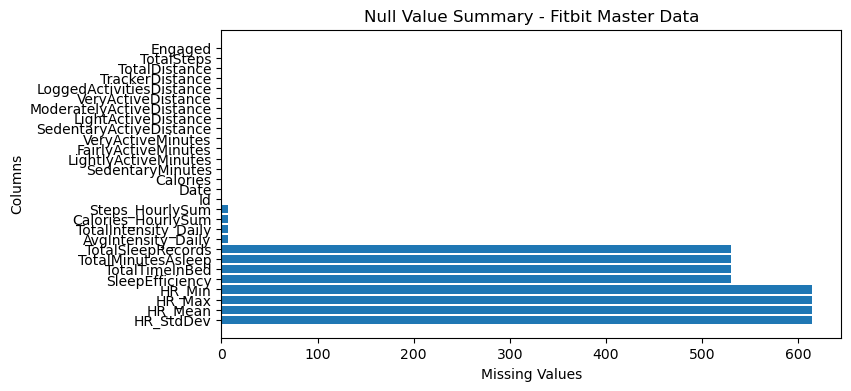

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert null summary to pandas for quick visualization
nulls_pd = null_summary.toPandas().T
nulls_pd.columns = ['MissingCount']
nulls_pd = nulls_pd.sort_values('MissingCount', ascending=False)

plt.figure(figsize=(8,4))
plt.barh(nulls_pd.index, nulls_pd['MissingCount'])
plt.xlabel('Missing Values')
plt.ylabel('Columns')
plt.title('Null Value Summary - Fitbit Master Data')
plt.show()
